<a href="https://colab.research.google.com/github/maria00med/EstadisticaVerano2026/blob/main/Problemario_U4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [la guía de la unidad 4](https://github.com/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.



---


**NOMBRE Y NÚMERO DE CONTROL**

Maria Guadalupe Medina Carrillo / 22150568


---



1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
método,minutos
A,6
B,7
C,11
D,10
A,8
B,9
C,16
D,12
A,7
B,10
C,11
D,11
A,8
B,8
C,13
D,9
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,método,minutos
0,A,6
1,B,7
2,C,11
3,D,10
4,A,8
5,B,9
6,C,16
7,D,12
8,A,7
9,B,10


In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/450fausto/EstadisticaVerano2026/refs/heads/main/problemarioU4/problema1.csv")
df

,metodo,minutos
0,A,6
1,B,7
2,C,11
3,D,10
4,A,8
5,B,9
6,C,16
7,D,12
8,A,7
9,B,10


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta
modelo = ols('minutos ~ C(metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.


,sum_sq,df,F,PR(>F)
C(metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.2808008139238355


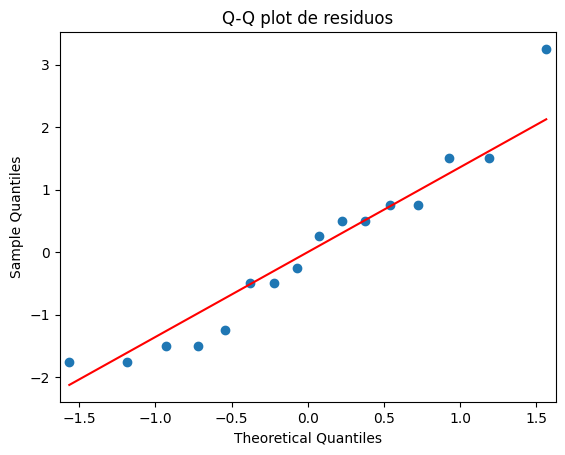

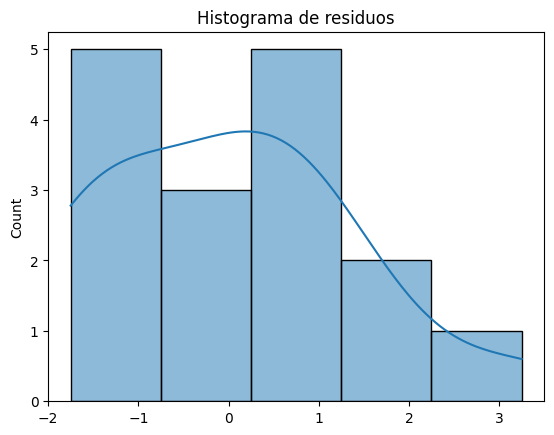

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_M1 = df[df['metodo'] == 'A']['minutos']
grupo_M2 = df[df['metodo'] == 'B']['minutos']
grupo_M3 = df[df['metodo'] == 'C']['minutos']
grupo_M4 = df[df['metodo'] == 'D']['minutos']

stat, p = levene(grupo_M1, grupo_M2, grupo_M3, grupo_M4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9474
p-valor: 0.4485


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

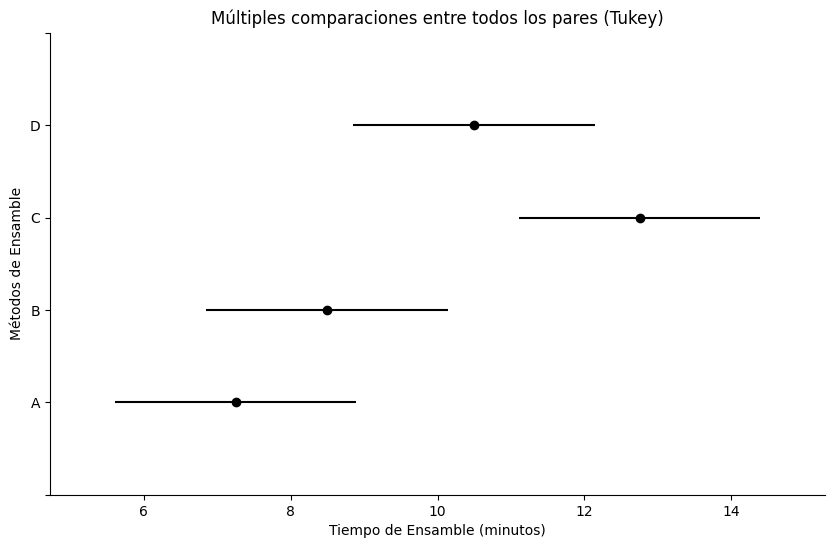

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['minutos'], # Variable de respuesta
    groups=df['metodo'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos de Ensamble", xlabel="Tiempo de Ensamble (minutos)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método

df.groupby(["metodo"]).mean()["minutos"]

,minutos
metodo,
A,7.25
B,8.50
C,12.75
D,10.50


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(metodo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.702


## Conclusión

El diseño experimental es un DCA (diseño completamente aleatorio) que cumple con los supuestos de normalidad y homoscedasticidad. Según el test de ANOVA hay diferencia significativa en al menos un método. Haciendo el test de Tuket se encuentra en el método C aumenta el tiempo de ensamble, por lo que recomendamos evitarlo y usar en cambio el método A, B o D. Aunque el método A mostró mejos resultados en este experimento, no se econtró una diferencia significativa con los métodos B o D.


---



2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Tipo_de_cuero,Observaciones
A,264
A,260
A,258
A,241
A,262
A,255
B,208
B,220
B,216
B,200
B,213
B,206
C,220
C,263
C,219
C,225
C,230
C,228
D,217
D,226
D,215
D,227
D,220
D,222
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tipo_de_cuero,Observaciones
0,A,264
1,A,260
2,A,258
3,A,241
4,A,262
5,A,255
6,B,208
7,B,220
8,B,216
9,B,200


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3 = mu_4
# H1: al menos una media es diferente

# variable de respuesta
modelo = ols('Observaciones ~ C(Tipo_de_cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tipo_de_cuero),7019.4583,3.0,22.7554,0.0
Residual,2056.5000,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.00967014513830024


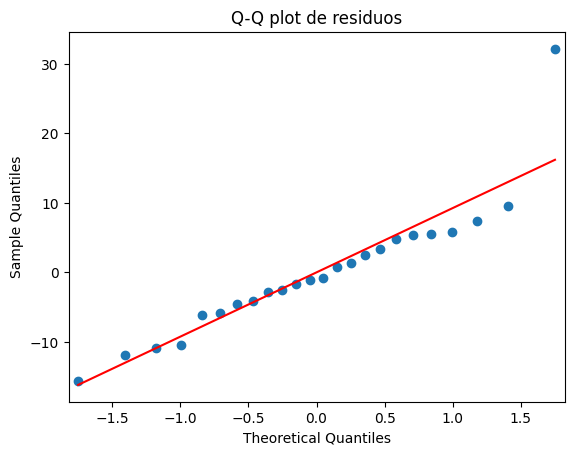

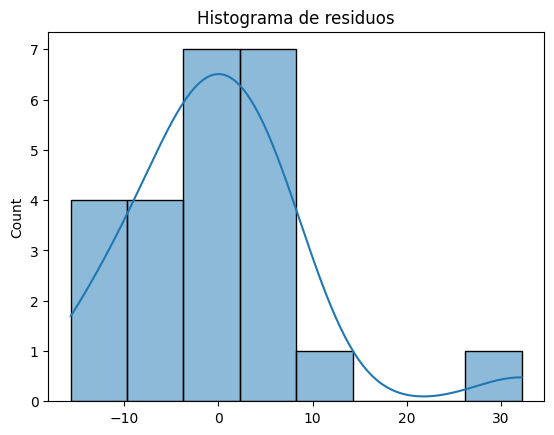

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_M1 = df[df['Tipo_de_cuero'] == 'A']['Observaciones']
grupo_M2 = df[df['Tipo_de_cuero'] == 'B']['Observaciones']
grupo_M3 = df[df['Tipo_de_cuero'] == 'C']['Observaciones']
grupo_M4 = df[df['Tipo_de_cuero'] == 'D']['Observaciones']

stat, p = levene(grupo_M1, grupo_M2, grupo_M3, grupo_M4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5797
p-valor: 0.6351


Lambda óptimo: -3.707788382033557


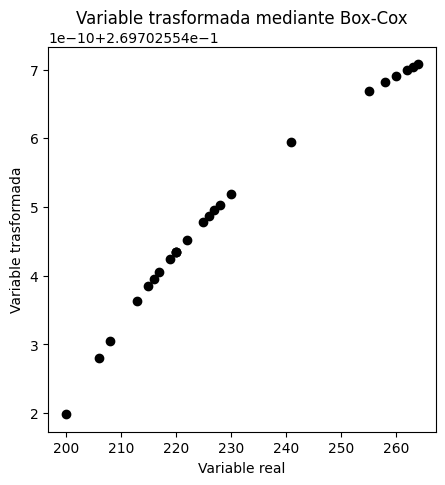

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["observaciones_boxcox"], lambda_opt = boxcox(df["Observaciones"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Observaciones"], df["observaciones_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3 = mu_4
# H1: al menos una media es diferente

# variable de respuesta
modelo = ols('observaciones_boxcox~ C(Tipo_de_cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tipo_de_cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.4576953738713335


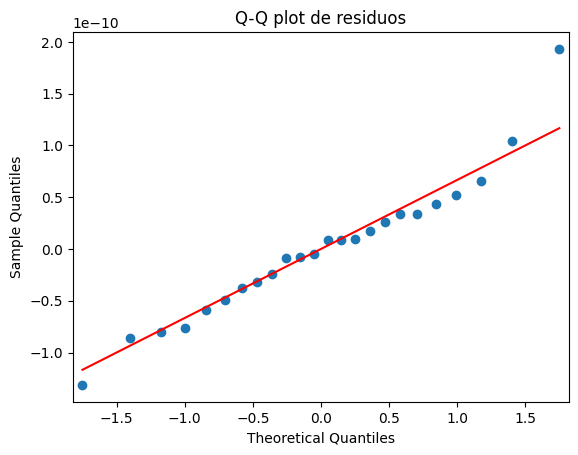

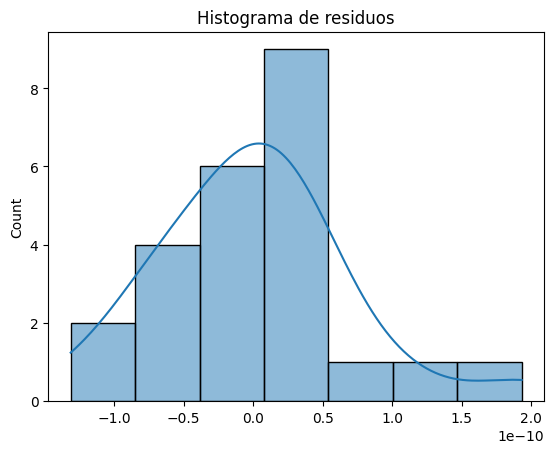

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_M1 = df[df['Tipo_de_cuero'] == 'A']['observaciones_boxcox']
grupo_M2 = df[df['Tipo_de_cuero'] == 'B']['observaciones_boxcox']
grupo_M3 = df[df['Tipo_de_cuero'] == 'C']['observaciones_boxcox']
grupo_M4 = df[df['Tipo_de_cuero'] == 'D']['observaciones_boxcox']

stat, p = levene(grupo_M1, grupo_M2, grupo_M3, grupo_M4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1788
p-valor: 0.3428


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3 = mu_4
# H1: al menos una media es diferente

# variable de respuesta
modelo = ols('observaciones_boxcox~ C(Tipo_de_cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tipo_de_cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

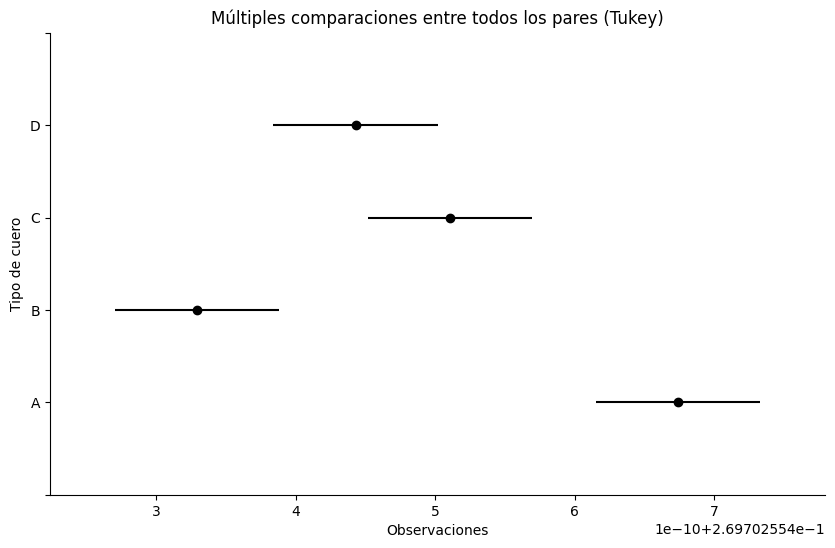

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['observaciones_boxcox'], # Variable de respuesta
    groups=df['Tipo_de_cuero'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipo de cuero", xlabel="Observaciones")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Conclusión
El experimento confirmó diferencias significativas en la resistencia al desgaste entre los cuatro tipos de cuero. La prueba de Tukey determinó que el cuero tipo A presenta el mayor desgaste, por lo que se recomienda evitar su uso. En contraste, el tipo B mostró la mayor resistencia, posicionándose junto a los tipos C y D como las mejores alternativas para minimizar la degradación de la suela.
B y D son los tipos con menor desgaste.



---



3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Tiempo_de_cocción_en_minutos
T1,213
T1,214
T1,204
T1,208
T1,212
T1,200
T1,207
T2,76
T2,85
T2,74
T2,78
T2,82
T2,75
T2,82
T3,57
T3,67
T3,55
T3,64
T3,61
T3,63
T3,63
T4,84
T4,82
T4,85
T4,92
T4,87
T4,79
T4,90
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tratamiento,Tiempo_de_cocción_en_minutos
0,T1,213
1,T1,214
2,T1,204
3,T1,208
4,T1,212
5,T1,200
6,T1,207
7,T2,76
8,T2,85
9,T2,74


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Tiempo_de_cocción_en_minutos ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.34689165649616827


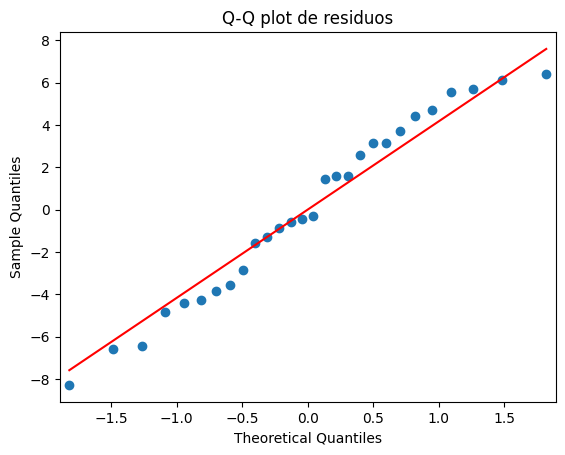

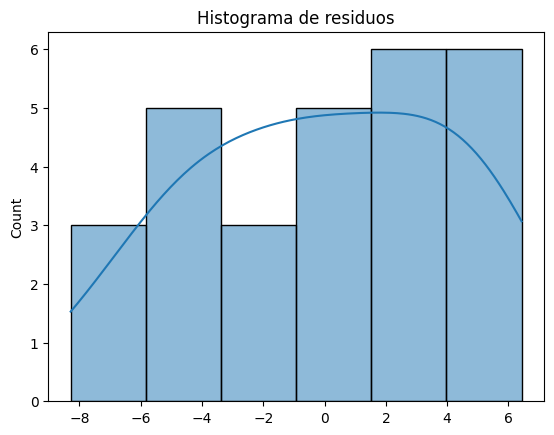

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

grupo_T1 = df[df['Tratamiento'] == 'T1']['Tiempo_de_cocción_en_minutos']
grupo_T2 = df[df['Tratamiento'] == 'T2']['Tiempo_de_cocción_en_minutos']
grupo_T3 = df[df['Tratamiento'] == 'T3']['Tiempo_de_cocción_en_minutos']
grupo_T4 = df[df['Tratamiento'] == 'T4']['Tiempo_de_cocción_en_minutos']

stat, p = levene(grupo_T1, grupo_T2, grupo_T3, grupo_T4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1631
p-valor: 0.9201


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Tiempo_de_cocción_en_minutos ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

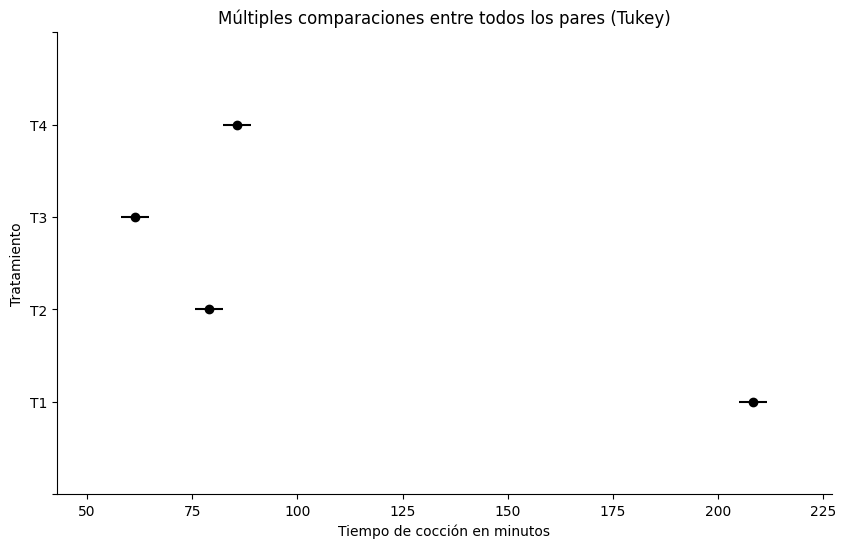

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Tiempo_de_cocción_en_minutos'], # Variable de respuesta
    groups=df['Tratamiento'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tratamiento", xlabel="Tiempo de cocción en minutos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


##Conclusión

El experimento comparó el efecto de cuatro tratamientos en el tiempo de cocción de los frijoles ($T_1$: control, $T_2$: bicarbonato, $T_3$: sal, $T_4$: mezcla). Tras validar los supuestos estadísticos, el análisis de varianza (ANOVA) confirmó diferencias significativas entre los tratamientos. La prueba de Tukey demostró que todos los tratamientos reducen drásticamente el tiempo de cocción frente al control ($T_1$), siendo el tratamiento $T_3$ (sal) el más efectivo para disminuirlo. Por lo tanto, se recomienda implementar el tratamiento con sal ($T_3$) para optimizar el proceso de cocción.
T2 y T3 son los tratamientos con menor tiempo de cocción.


---



4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Temperatura,Intensidad_de_corriente
20°C,15
20°C,18
20°C,13
20°C,12
40°C,17
40°C,21
40°C,11
40°C,16
60°C,23
60°C,19
60°C,25
60°C,22
80°C,28
80°C,32
80°C,34
80°C,31
100°C,45
100°C,51
100°C,57
100°C,48
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Temperatura,Intensidad_de_corriente
0,20°C,15
1,20°C,18
2,20°C,13
3,20°C,12
4,40°C,17
5,40°C,21
6,40°C,11
7,40°C,16
8,60°C,23
9,60°C,19


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Intensidad_de_corriente ~ C(Temperatura)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Temperatura),3411.8,4.0,68.0545,0.0
Residual,188.0,15.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7785351257478148


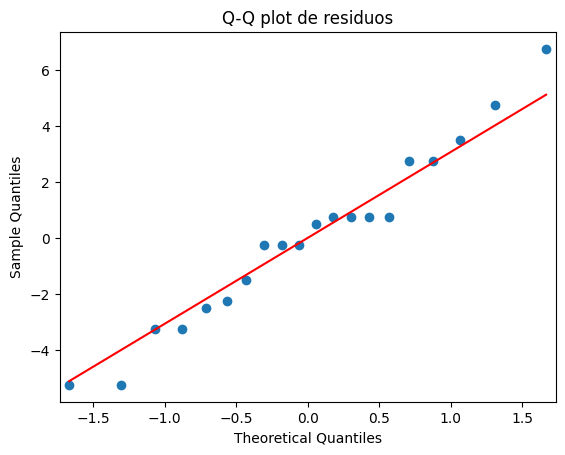

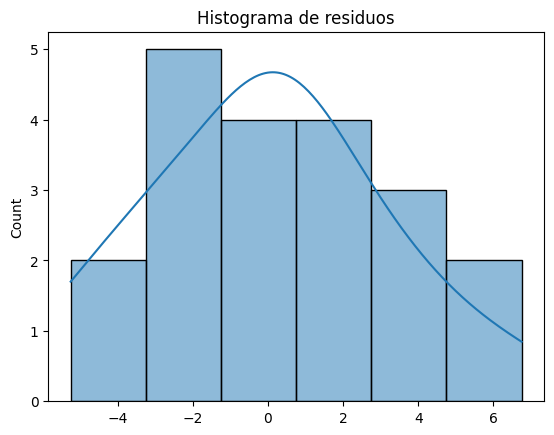

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
import pandas as pd
from io import StringIO
from scipy.stats import levene

# Cargar los datos del Problema 4
datos = '''
Temperatura,Intensidad_de_corriente
20°C,15
20°C,18
20°C,13
20°C,12
40°C,17
40°C,21
40°C,11
40°C,16
60°C,23
60°C,19
60°C,25
60°C,22
80°C,28
80°C,32
80°C,34
80°C,31
100°C,45
100°C,51
100°C,57
100°C,48
'''
df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

# Separar por grupos
# Se han corregido los nombres de las variables para eliminar el carácter '°'
# y se han actualizado los valores de 'Temperatura' y la variable de respuesta
# para que coincidan con el Problema 4.

grupo_20_C = df[df['Temperatura'] == '20°C']['Intensidad_de_corriente']
grupo_40_C = df[df['Temperatura'] == '40°C']['Intensidad_de_corriente']
grupo_60_C = df[df['Temperatura'] == '60°C']['Intensidad_de_corriente']
grupo_80_C = df[df['Temperatura'] == '80°C']['Intensidad_de_corriente']
grupo_100_C = df[df['Temperatura'] == '100°C']['Intensidad_de_corriente']
stat, p = levene(grupo_20_C, grupo_40_C, grupo_60_C, grupo_80_C, grupo_100_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.6808
p-valor: 0.6160


In [ ]:
from scipy.stats import levene

# Get unique temperature levels from the DataFrame
temperatura_levels = df['Temperatura'].unique()

# Create a list to hold the groups dynamically
grupos = []
for level in temperatura_levels:
    grupos.append(df[df['Temperatura'] == level]['Intensidad_de_corriente'])

# Pass the groups to the levene test using the unpacking operator (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.6808
p-valor: 0.6160


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Intensidad_de_corriente ~ C(Temperatura)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Temperatura),3411.8,4.0,68.0545,0.0
Residual,188.0,15.0,NaN,NaN


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
 100°C   20°C   -35.75    0.0 -43.4801 -28.0199   True
 100°C   40°C    -34.0    0.0 -41.7301 -26.2699   True
 100°C   60°C    -28.0    0.0 -35.7301 -20.2699   True
 100°C   80°C    -19.0    0.0 -26.7301 -11.2699   True
  20°C   40°C     1.75 0.9535  -5.9801   9.4801  False
  20°C   60°C     7.75 0.0493   0.0199  15.4801   True
  20°C   80°C    16.75 0.0001   9.0199  24.4801   True
  40°C   60°C      6.0 0.1696  -1.7301  13.7301  False
  40°C   80°C     15.0 0.0002   7.2699  22.7301   True
  60°C   80°C      9.0 0.0191   1.2699  16.7301   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

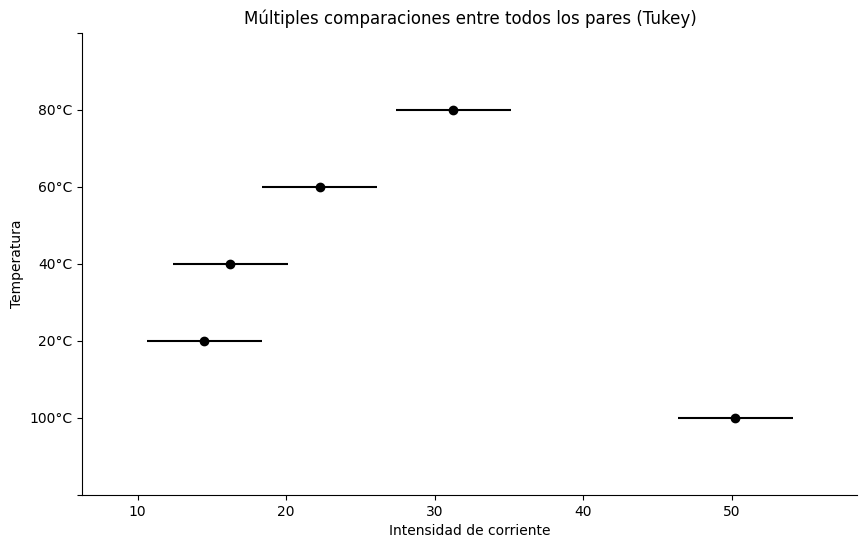

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Intensidad_de_corriente'], # Variable de respuesta
    groups=df['Temperatura'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Temperatura", xlabel="Intensidad de corriente")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

##Conclusión
20°C y 40°C
El experimento evaluó el efecto de cinco niveles de temperatura (20°C a 100°C) sobre la intensidad de corriente en tableros electrónicos tras un envejecimiento acelerado. El análisis de varianza (ANOVA) confirma diferencias significativas en el deterioro de los módulos según la temperatura aplicada ($p < 0.05$). Los resultados indican que a mayor temperatura, aumenta proporcionalmente la intensidad de corriente, evidenciando un mayor deterioro. Por lo tanto, se concluye que la temperatura es un factor crítico en la fiabilidad de los componentes; se recomienda minimizar la exposición a temperaturas elevadas (80°C - 100°C) para prolongar la vida útil de los tableros.


---




5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Tratamiento,Porcentaje_de_producto_defectuoso
con_tratam.,5.3
con_tratam.,4.0
con_tratam.,4.0
con_tratam.,4.0
con_tratam.,2.6
con_tratam.,2.1
con_tratam.,5.1
con_tratam.,4.1
con_tratam.,4.1
con_tratam.,3.2
con_tratam.,5.1
con_tratam.,2.2
con_tratam.,4.1
sin_tratam.,8.0
sin_tratam.,13.2
sin_tratam.,7.2
sin_tratam.,8.2
sin_tratam.,9.1
sin_tratam.,6.7
sin_tratam.,12.6
sin_tratam.,16.3
sin_tratam.,9.2
sin_tratam.,6.4
sin_tratam.,7.2
sin_tratam.,17.2
sin_tratam.,12.3
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Tratamiento,Porcentaje_de_producto_defectuoso
0,con_tratam.,5.3
1,con_tratam.,4.0
2,con_tratam.,4.0
3,con_tratam.,4.0
4,con_tratam.,2.6
5,con_tratam.,2.1
6,con_tratam.,5.1
7,con_tratam.,4.1
8,con_tratam.,4.1
9,con_tratam.,3.2


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

modelo = ols('Porcentaje_de_producto_defectuoso ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.08240142335256262


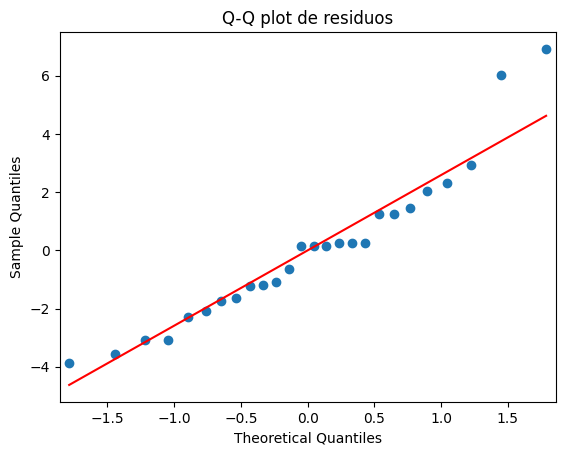

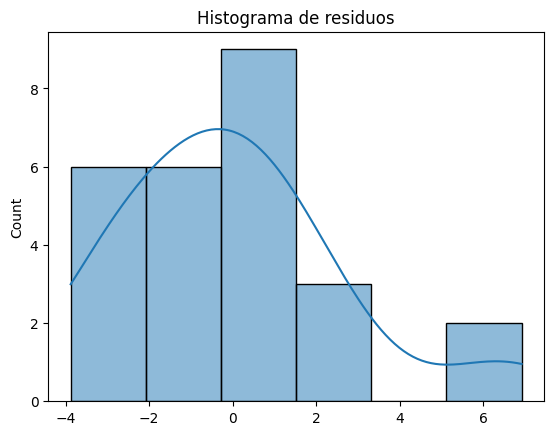

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Get unique treatment levels from the DataFrame
tratamiento_levels = df['Tratamiento'].unique()

# Create a list to hold the groups dynamically
grupos = []
for level in tratamiento_levels:
    grupos.append(df[df['Tratamiento'] == level]['Porcentaje_de_producto_defectuoso'])

# Pass the groups to the levene test using the unpacking operator (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 8.7144
p-valor: 0.0070


Lambda óptimo: -0.05387226813423122


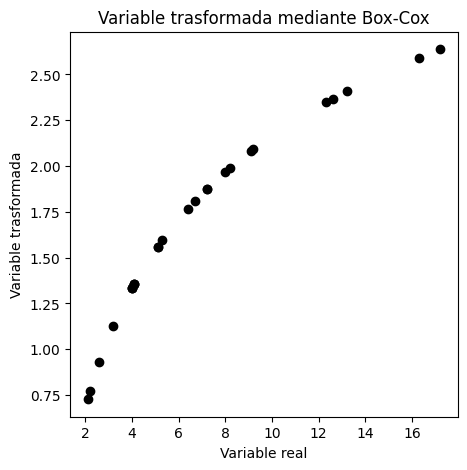

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["porcentaje_de_producto_defectuoso_boxcox"], lambda_opt = boxcox(df["Porcentaje_de_producto_defectuoso"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["Porcentaje_de_producto_defectuoso"], df["porcentaje_de_producto_defectuoso_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

modelo = ols('porcentaje_de_producto_defectuoso_boxcox ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),5.0403,1.0,58.8438,0.0
Residual,2.0557,24.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.5855089546322916


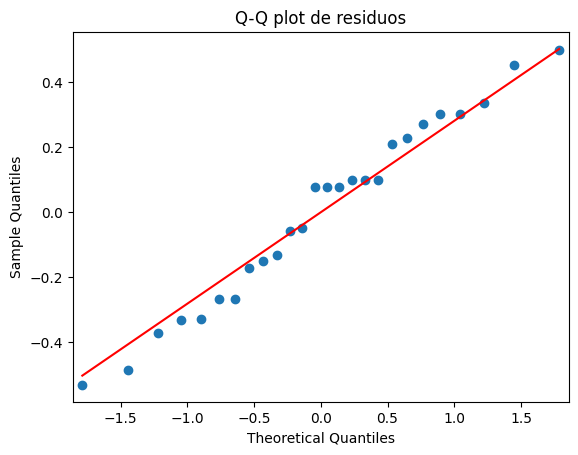

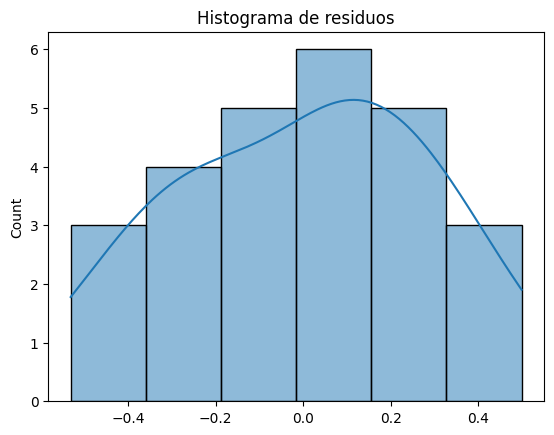

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Get unique treatment levels from the DataFrame
tratamiento_levels = df['Tratamiento'].unique()

# Create a list to hold the groups dynamically
grupos = []
for level in tratamiento_levels:
    grupos.append(df[df['Tratamiento'] == level]['porcentaje_de_producto_defectuoso_boxcox'])

# Pass the groups to the levene test using the unpacking operator (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.3797
p-valor: 0.5436


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

modelo = ols('porcentaje_de_producto_defectuoso_boxcox ~ C(Tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento),5.0403,1.0,58.8438,0.0
Residual,2.0557,24.0,NaN,NaN


    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
   group1      group2   meandiff p-adj lower  upper  reject
-----------------------------------------------------------
con_tratam. sin_tratam.   0.8806   0.0 0.6437 1.1175   True
-----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

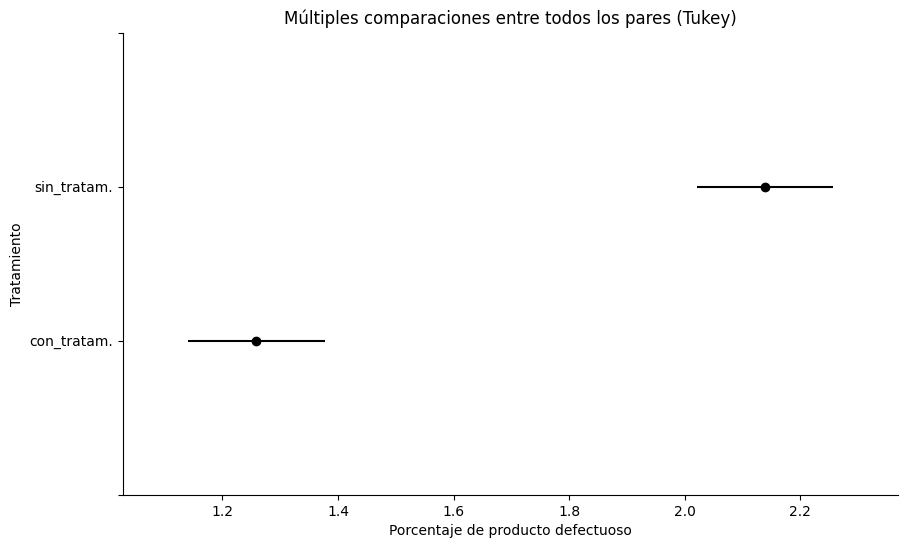

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['porcentaje_de_producto_defectuoso_boxcox'], # Variable de respuesta
    groups=df['Tratamiento'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tratamiento", xlabel="Porcentaje de producto defectuoso")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


## Conclusión
El experimento evaluó la efectividad de un tratamiento propuesto para reducir el porcentaje de productos defectuosos, comparando su desempeño frente a la producción sin dicho tratamiento. Tras el análisis estadístico, se confirmó una diferencia significativa en la reducción de defectos al aplicar la mejora. Los datos evidencian que el grupo "Con tratamiento" presenta un porcentaje de productos defectuosos notablemente menor y más estable que el grupo "Sin tratamiento", cuya variabilidad y tasas de error son significativamente más altas. Por lo tanto, se recomienda implementar el tratamiento propuesto de manera permanente, ya que su aplicación disminuye eficazmente la tasa de defectos en la producción.
Con tratimiento se reduce el porcentaje de defectuosas.


---



6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
%_de_almidón,Dureza
2,4.3
2,5.2
2,4.8
2,4.5
5,6.5
5,7.3
5,6.9
5,6.1
10,9.0
10,7.8
10,8.5
10,8.1
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,%_de_almidón,Dureza
0,2,4.3
1,2,5.2
2,2,4.8
3,2,4.5
4,5,6.5
5,5,7.3
6,5,6.9
7,5,6.1
8,10,9.0
9,10,7.8


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# Renombrar la columna para evitar problemas con caracteres especiales en la fórmula
df = df.rename(columns={'%_de_almidón': 'Almidon'})

modelo = ols('Dureza ~ C(Almidon)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Almidon),26.7267,2.0,58.1014,0.0
Residual,2.0700,9.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42952068080371164


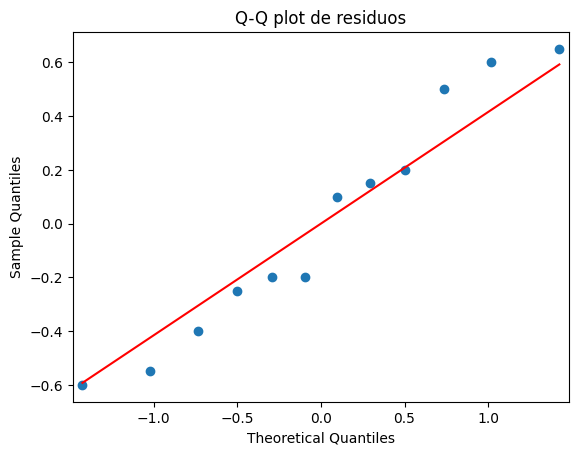

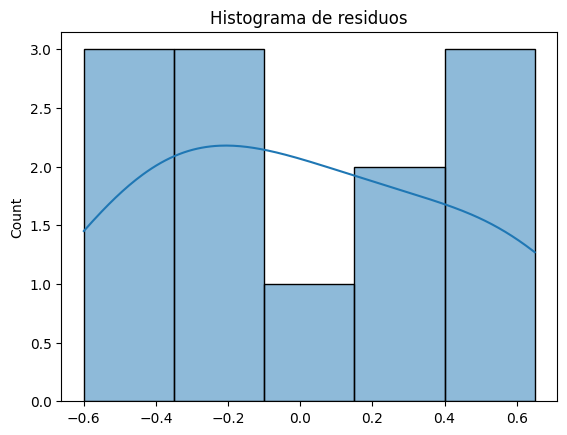

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_2 = df[df['Almidon'] == 2]['Dureza']
grupo_5 = df[df['Almidon'] == 5]['Dureza']
grupo_10 = df[df['Almidon'] == 10]['Dureza']

stat, p = levene(grupo_2, grupo_5, grupo_10)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2667
p-valor: 0.7718


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Dureza ~ C(Almidon)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Almidon),26.7267,2.0,58.1014,0.0
Residual,2.0700,9.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     2      5      2.0 0.0006 1.0532 2.9468   True
     2     10     3.65    0.0 2.7032 4.5968   True
     5     10     1.65 0.0023 0.7032 2.5968   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

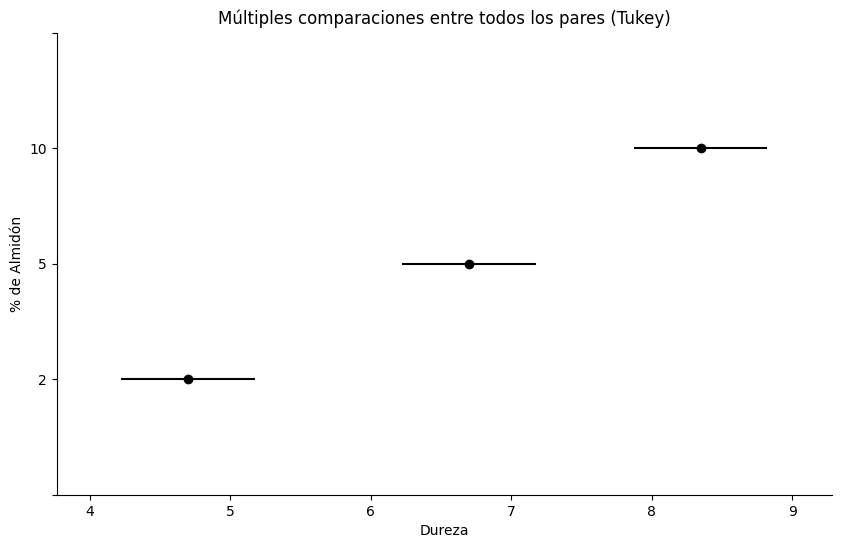

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Dureza'], # Variable de respuesta
    groups=df['Almidon'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="% de Almidón", xlabel="Dureza")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Niveles_de_nitrógeno,Rendimientos
1,14.823
1,14.676
1,14.720
1,14.5141
1,15.065
2,25.151
2,25.401
2,25.131
2,25.031
2,25.267
3,32.605
3,32.460
3,32.256
3,32.669
3,32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Niveles_de_nitrógeno,Rendimientos
0,1,14.8230
1,1,14.6760
2,1,14.7200
3,1,14.5141
4,1,15.0650
5,2,25.1510
6,2,25.4010
7,2,25.1310
8,2,25.0310
9,2,25.2670


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Rendimientos ~ C(Niveles_de_nitrógeno)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Niveles_de_nitrógeno),788.3408,2.0,10131.6193,0.0
Residual,0.4669,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.8890610190283172


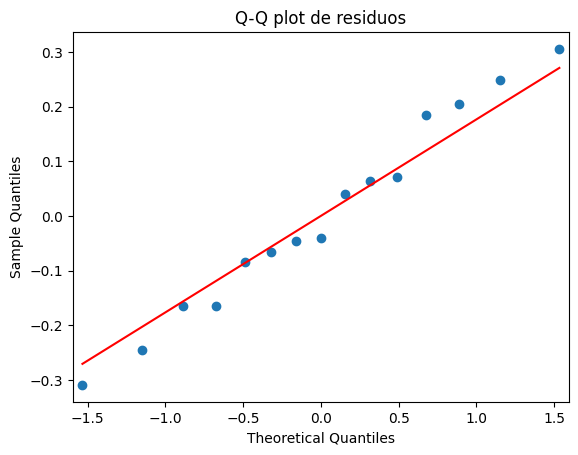

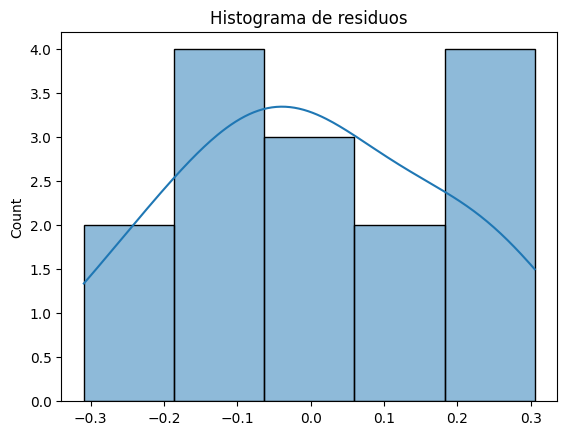

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Obtener los niveles únicos de la variable categórica
nitrogeno_levels = df['Niveles_de_nitrógeno'].unique()

# Crear una lista para almacenar los grupos dinámicamente
grupos = []
for level in nitrogeno_levels:
    grupos.append(df[df['Niveles_de_nitrógeno'] == level]['Rendimientos'])

# Pasar los grupos a la prueba de Levene usando el operador de desempaquetado (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5372
p-valor: 0.5978


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Rendimientos ~ C(Niveles_de_nitrógeno)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Niveles_de_nitrógeno),788.3408,2.0,10131.6193,0.0
Residual,0.4669,12.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2  10.4366   0.0 10.1038 10.7694   True
     1      3  17.6606   0.0 17.3278 17.9934   True
     2      3    7.224   0.0  6.8912  7.5568   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

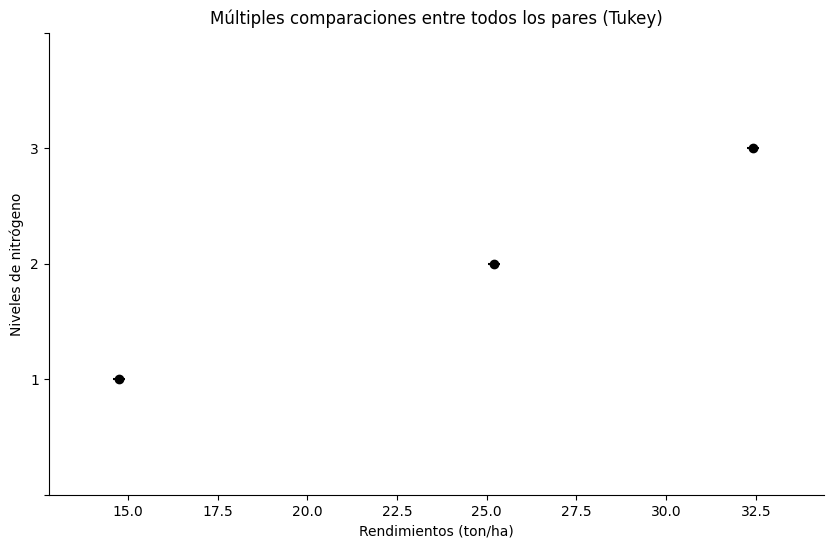

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Rendimientos'], # Variable de respuesta
    groups=df['Niveles_de_nitrógeno'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Niveles de nitrógeno", xlabel="Rendimientos (ton/ha)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Conclusión
El experimento evaluó el efecto de tres concentraciones de almidón (2%, 5% y 10%) sobre la dureza de las tabletas. El análisis de varianza (ANOVA) confirma que existen diferencias estadísticamente significativas en la dureza según la cantidad de almidón utilizada. Los resultados muestran una relación directa y positivapositiva porque a mayor porcentaje de almidón, se observa un incremento en la dureza promedio de las tabletas. Por lo tanto, se concluye que la cantidad de almidón es un factor determinante en la consistencia del producto; se recomienda ajustar el porcentaje según el nivel de dureza requerido para el estándar de calidad deseado.



---



8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Aglutinante,%_de_frianilidad
PVP,0.485
PVP,0.250
PVP,0.073
PVP,0.205
PVP,0.161
CMC,9.64
CMC,9.37
CMC,9.53
CMC,9.86
CMC,9.79
Gre,0.289
Gre,0.275
Gre,0.612
Gre,0.152
Gre,0.137
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Aglutinante,%_de_frianilidad
0,PVP,0.485
1,PVP,0.250
2,PVP,0.073
3,PVP,0.205
4,PVP,0.161
5,CMC,9.640
6,CMC,9.370
7,CMC,9.530
8,CMC,9.860
9,CMC,9.790


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# Renombrar la columna para evitar problemas con caracteres especiales en la fórmula
df = df.rename(columns={'%_de_frianilidad': 'Frianilidad'})

modelo = ols('Frianilidad ~ C(Aglutinante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Aglutinante),292.9210,2.0,4420.9726,0.0
Residual,0.3975,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42143454193876007


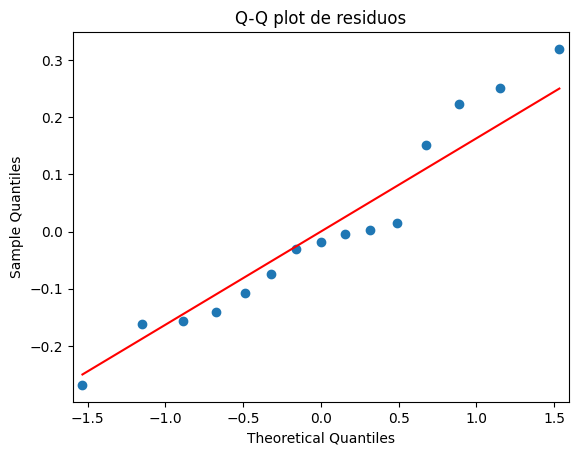

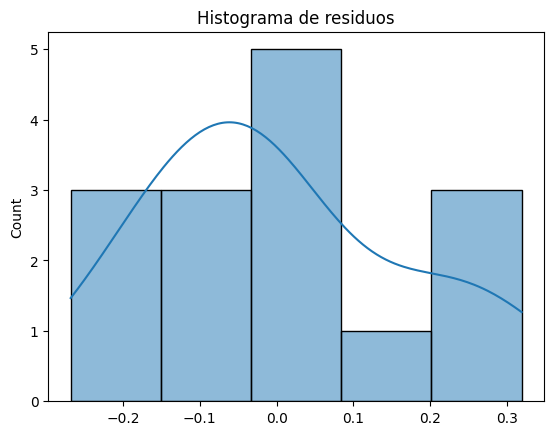

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# Obtener los niveles únicos de la variable categórica
aglutinante_levels = df['Aglutinante'].unique()

# Crear una lista para almacenar los grupos dinámicamente
grupos = []
for level in aglutinante_levels:
    grupos.append(df[df['Aglutinante'] == level]['Frianilidad'])

# Pasar los grupos a la prueba de Levene usando el operador de desempaquetado (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2250
p-valor: 0.8018


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Frianilidad ~ C(Aglutinante)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Aglutinante),292.9210,2.0,4420.9726,0.0
Residual,0.3975,12.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   CMC    Gre   -9.345   0.0 -9.6521 -9.0379   True
   CMC    PVP  -9.4032   0.0 -9.7103 -9.0961   True
   Gre    PVP  -0.0582  0.87 -0.3653  0.2489  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

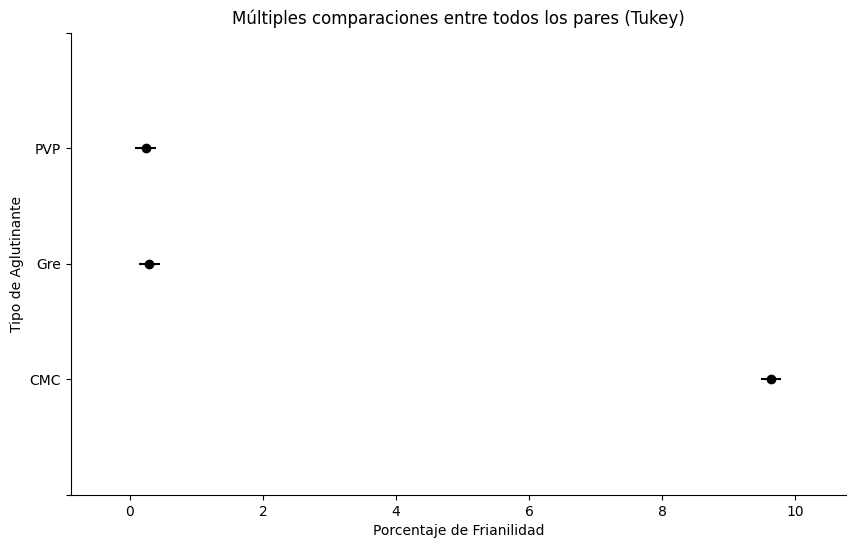

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Frianilidad'], # Variable de respuesta
    groups=df['Aglutinante'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipo de Aglutinante", xlabel="Porcentaje de Frianilidad")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Conclusión
El experimento evaluó el impacto de tres tipos de aglutinantes (PVP, CMC y Grenetina) en el porcentaje de friabilidad de tabletas de ampicilina. El análisis de varianza (ANOVA) confirma la existencia de diferencias estadísticamente significativas en la friabilidad según el aglutinante empleado. La prueba de comparaciones múltiples revela que el uso de CMC resulta en un porcentaje de friabilidad drásticamente superior al de los otros dos, lo que indica una menor integridad física de la tableta. Por el contrario, PVP y Grenetina presentan valores de friabilidad significativamente menores, por tanto, se recomienda evitar el uso de CMC y optar por PVP o Grenetina para garantizar una mayor resistencia mecánica en la fabricación de las tabletas.


---



9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Clona,Porcentaje_de_azúcares_reductores_totales
1,8.69
1,6.68
1,6.83
1,6.43
1,10.30
2,8.00
2,16.41
2,12.43
2,10.99
2,15.53
3,17.39
3,13.73
3,15.62
3,17.05
3,15.42
4,10.37
4,9.16
4,8.83
4,4.40
4,10.38

'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Clona,Porcentaje_de_azúcares_reductores_totales
0,1,8.69
1,1,6.68
2,1,6.83
3,1,6.43
4,1,10.30
5,2,8.00
6,2,16.41
7,2,12.43
8,2,10.99
9,2,15.53


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Porcentaje_de_azúcares_reductores_totales ~ C(Clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7677173153296


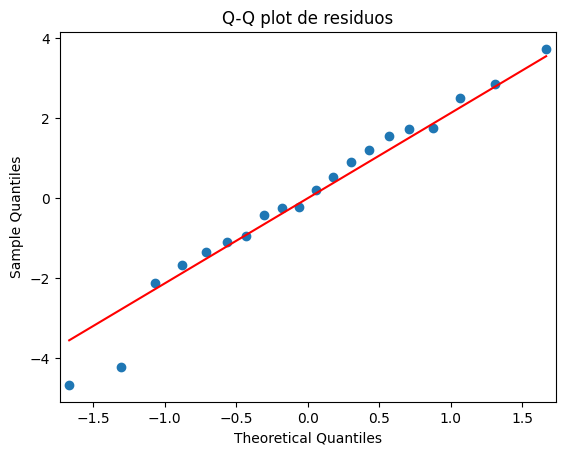

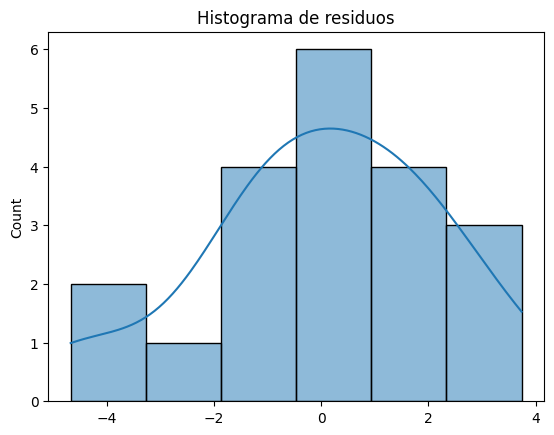

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# Obtener los niveles únicos de la variable categórica
clona_levels = df['Clona'].unique()

# Crear una lista para almacenar los grupos dinámicamente
grupos = []
for level in clona_levels:
    grupos.append(df[df['Clona'] == level]['Porcentaje_de_azúcares_reductores_totales'])

# Pasar los grupos a la prueba de Levene usando el operador de desempaquetado (*)
stat, p = levene(*grupos)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9749
p-valor: 0.4290


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('Porcentaje_de_azúcares_reductores_totales ~ C(Clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2    4.886 0.0237   0.575  9.197   True
     1      3    8.056 0.0003   3.745 12.367   True
     1      4    0.842 0.9428  -3.469  5.153  False
     2      3     3.17 0.1939  -1.141  7.481  False
     2      4   -4.044 0.0699  -8.355  0.267  False
     3      4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

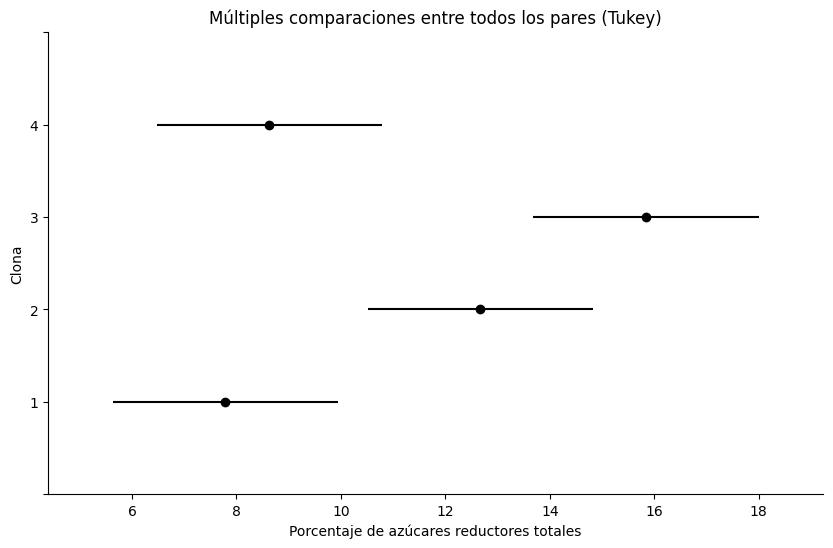

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Porcentaje_de_azúcares_reductores_totales'], # Variable de respuesta
    groups=df['Clona'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Clona", xlabel="Porcentaje de azúcares reductores totales")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Conclusión

El experimento evaluó la respuesta de cuatro clones de Agave tequilana ante un mismo esquema de manejo, midiendo el porcentaje de azúcares reductores totales. El ANOVA confirma que existen diferencias estadísticamente significativas entre las respuestas de los distintos clones. Al comparar los resultados, el clon 3 presenta consistentemente los niveles más altos de azúcares reductores, lo que indica una mejor respuesta y mayor productividad bajo las condiciones de manejo aplicadas. Por lo tanto, se concluye que el clon 3 es la opción más eficiente y se recomienda su selección para optimizar el rendimiento de azúcares en la producción.


---



10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Con_Tratamiento,Sin_Tratamiento
5.30,8.02
4.03,13.18
4.00,7.15
2.56,9.11
5.06,8.23
4.06,16.3
2.08,9.20
4.03,6.35
2.04,7.15
1.18,8.66

'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Con_Tratamiento,Sin_Tratamiento
0,5.30,8.02
1,4.03,13.18
2,4.00,7.15
3,2.56,9.11
4,5.06,8.23
5,4.06,16.30
6,2.08,9.20
7,4.03,6.35
8,2.04,7.15
9,1.18,8.66


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

# Reshape the DataFrame from wide to long format
df_long = df.melt(var_name='Tratamiento_Tipo', value_name='Porcentaje_Cometas')

modelo = ols('Porcentaje_Cometas ~ C(Tratamiento_Tipo)', data=df_long).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento_Tipo),174.1090,1.0,30.6057,0.0
Residual,102.3981,18.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.013152795271816857


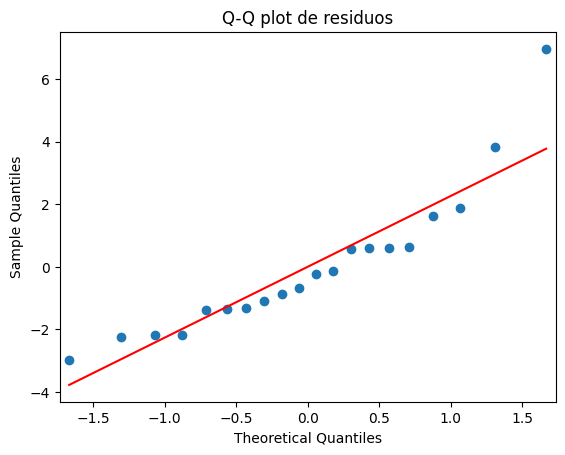

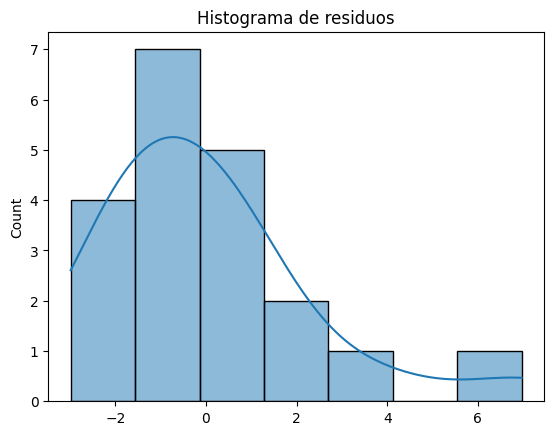

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()


In [ ]:
from scipy.stats import levene

# Separar por grupos para Problem 10
grupo_con_tratamiento = df_long[df_long['Tratamiento_Tipo'] == 'Con_Tratamiento']['Porcentaje_Cometas']
grupo_sin_tratamiento = df_long[df_long['Tratamiento_Tipo'] == 'Sin_Tratamiento']['Porcentaje_Cometas']

stat, p = levene(grupo_con_tratamiento, grupo_sin_tratamiento)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1180
p-valor: 0.3043


Lambda óptimo: 0.32061169162391906


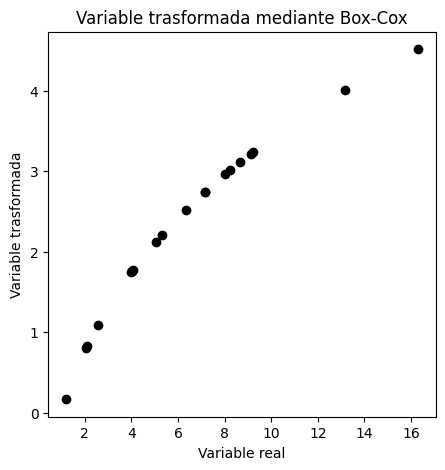

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df_long["Porcentaje_Cometas_boxcox"], lambda_opt = boxcox(df_long["Porcentaje_Cometas"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df_long["Porcentaje_Cometas"], df_long["Porcentaje_Cometas_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

# Usar la variable transformada Box-Cox
modelo = ols('Porcentaje_Cometas_boxcox ~ C(Tratamiento_Tipo)', data=df_long).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento_Tipo),15.8598,1.0,38.9108,0.0
Residual,7.3367,18.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.9455348310737177


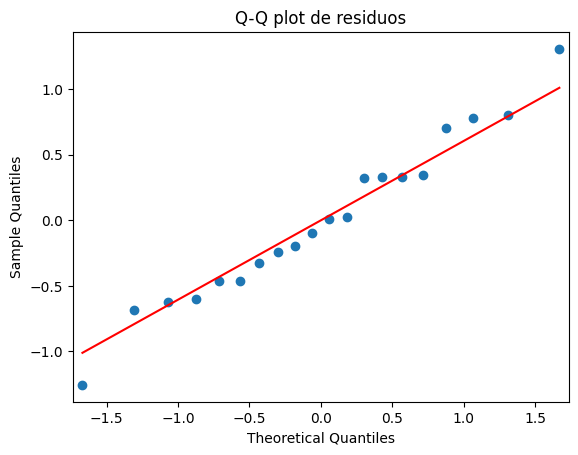

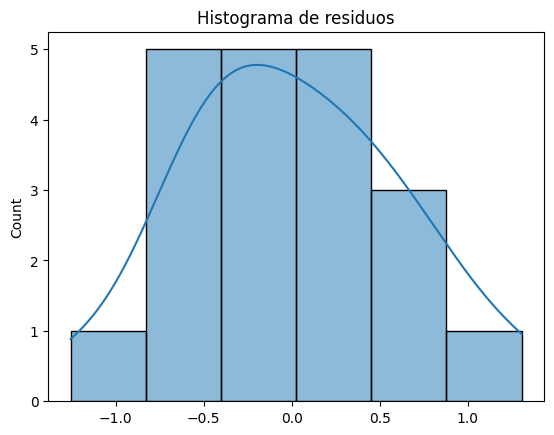

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos para el Problema 10 usando df_long
grupo_con_tratamiento = df_long[df_long['Tratamiento_Tipo'] == 'Con_Tratamiento']['Porcentaje_Cometas_boxcox']
grupo_sin_tratamiento = df_long[df_long['Tratamiento_Tipo'] == 'Sin_Tratamiento']['Porcentaje_Cometas_boxcox']

stat, p = levene(grupo_con_tratamiento, grupo_sin_tratamiento)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1523
p-valor: 0.7009


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2
# H1: al menos una media es diferente

# Usar la variable transformada Box-Cox
modelo = ols('Porcentaje_Cometas_boxcox ~ C(Tratamiento_Tipo)', data=df_long).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Tratamiento_Tipo),15.8598,1.0,38.9108,0.0
Residual,7.3367,18.0,NaN,NaN


        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
     group1          group2     meandiff p-adj lower  upper  reject
-------------------------------------------------------------------
Con_Tratamiento Sin_Tratamiento    1.781   0.0 1.1812 2.3808   True
-------------------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

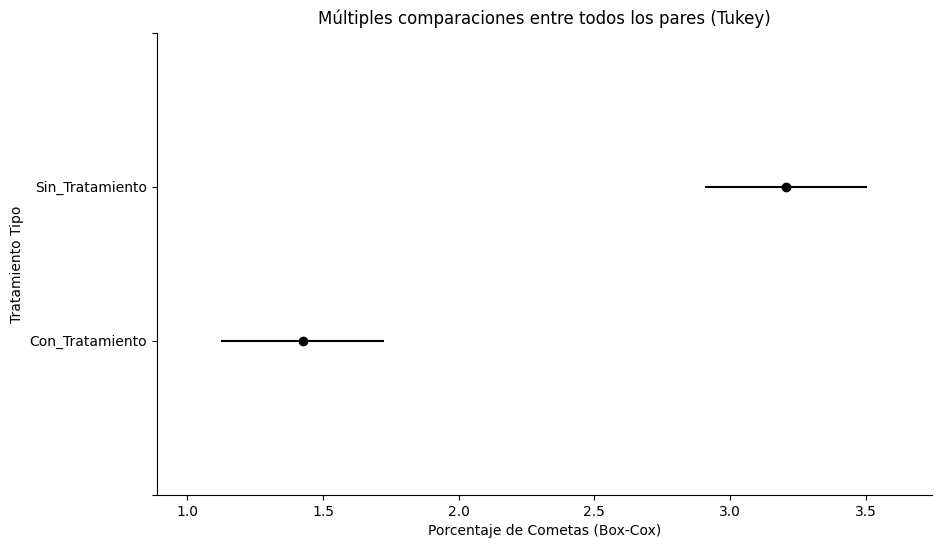

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df_long['Porcentaje_Cometas_boxcox'], # Variable de respuesta transformada
    groups=df_long['Tratamiento_Tipo'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tratamiento Tipo", xlabel="Porcentaje de Cometas (Box-Cox)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Conclusión
El experimento evaluó la eficacia de un tratamiento de limpieza (basado en fuerza centrípeta y aire ionizado) para reducir la aparición de defectos conocidos como "cometas" en la manufactura de discos ópticos. Tras el análisis estadístico, el ANOVA confirmó una diferencia significativa en el porcentaje de defectos entre los lotes tratados y los no tratados. Los datos demuestran que la aplicación del tratamiento reduce de forma consistente la incidencia de "cometas" en comparación con el proceso estándar. Por lo tanto, se concluye que el tratamiento es efectivo para mejorar la calidad del producto y se recomienda su implementación sistemática en la línea de producción para reducir los desperdicios derivados de este defecto.